## **My first ML Project**

>This project uses a Random Forest model to predict diabetes risk based on health indicators from the BRFSS dataset, achieving high accuracy and enabling early, cost-effective screening.


File not found, creating sample data…
Dataset shape: (1000, 11)

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   feature_0        1000 non-null   float64
 1   feature_1        1000 non-null   float64
 2   feature_2        1000 non-null   float64
 3   feature_3        1000 non-null   float64
 4   feature_4        1000 non-null   float64
 5   feature_5        1000 non-null   float64
 6   feature_6        1000 non-null   float64
 7   feature_7        1000 non-null   float64
 8   feature_8        1000 non-null   float64
 9   feature_9        1000 non-null   float64
 10  Diabetes_binary  1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB
None

Basic stats:
         feature_0    feature_1    feature_2    feature_3    feature_4  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000  

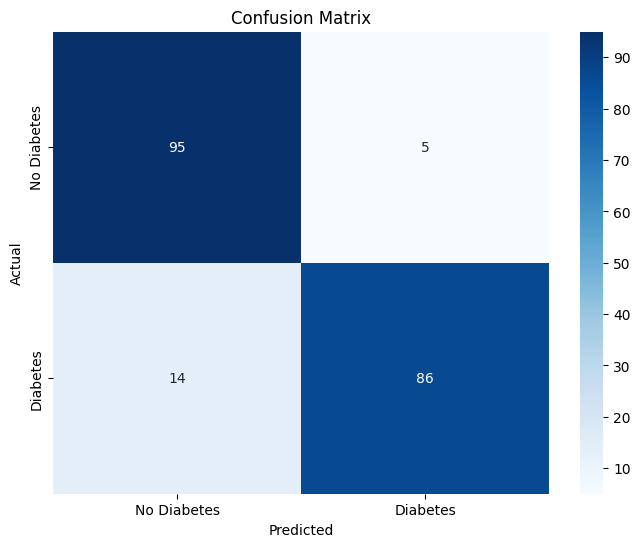


Top 10 important features:
     feature  importance
6  feature_6    0.390357
2  feature_2    0.221829
8  feature_8    0.126834
0  feature_0    0.104660
1  feature_1    0.029291
4  feature_4    0.027255
3  feature_3    0.026311
5  feature_5    0.025939
7  feature_7    0.024515
9  feature_9    0.023010


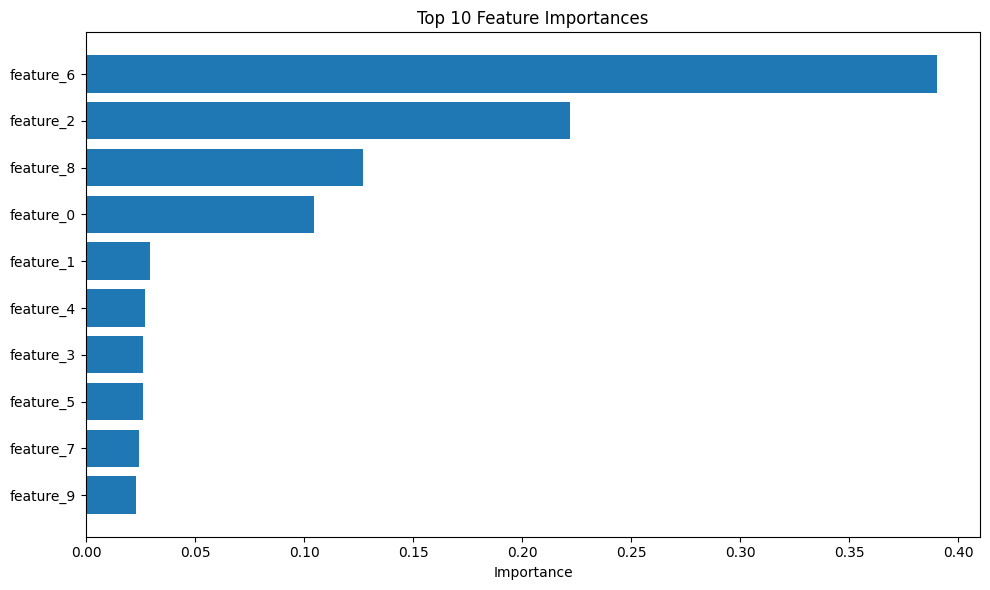


Model saved as: diabetes_random_forest_model.pkl
Scaler saved as: scaler.pkl

Sample Prediction:
Actual: Diabetes
Predicted: Diabetes
Probabilities: No Diabetes=8.78%, Diabetes=91.22%

Final Results - Random Forest:
Accuracy: 0.9050
F1 Score: 0.9005
Training completed!


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.feature_selection import VarianceThreshold
import joblib

# ========== Load data ==========
try:
    data = pd.read_csv("diabetes_binary_health_indicators_BRFSS2015.csv")
    print("Data loaded successfully!")
except FileNotFoundError:
    print("File not found, creating sample data…")
    from sklearn.datasets import make_classification
    X_tmp, y_tmp = make_classification(n_samples=1000, n_features=10, n_classes=2, random_state=42)
    data = pd.DataFrame(X_tmp, columns=[f"feature_{i}" for i in range(X_tmp.shape[1])])
    data["Diabetes_binary"] = y_tmp

print(f"Dataset shape: {data.shape}")
print("\nDataset info:")
print(data.info())
print("\nBasic stats:")
print(data.describe())

# Target distribution
if "Diabetes_binary" in data.columns:
    target_dist = data["Diabetes_binary"].value_counts()
    print("\nTarget distribution:")
    print(f"No Diabetes: {target_dist.get(0,0)}")
    print(f"Diabetes: {target_dist.get(1,0)}")

# Handle missing values (simple median fill)
missing = data.isnull().sum()
print("\nMissing values:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values")

if missing.sum() > 0:
    numeric_cols = data.select_dtypes(include=[np.number]).columns
    for col in numeric_cols:
        if data[col].isnull().sum() > 0:
            data[col].fillna(data[col].median(), inplace=True)
    print("Missing values handled.")

# Features/target
X = data.drop("Diabetes_binary", axis=1)
y = data["Diabetes_binary"]

# NOTE: Ideally do this inside a Pipeline to avoid leakage.
selector = VarianceThreshold(threshold=0.01)
X = pd.DataFrame(selector.fit_transform(X), columns=X.columns[selector.get_support()])
print(f"Features after variance filtering: {X.shape[1]}")

# Split
from sklearn.model_selection import StratifiedKFold
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled.")

# Random Forest + GridSearch
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
grid = GridSearchCV(rf_model, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train_scaled, y_train)
best_model = grid.best_estimator_
print(f"Best Random Forest F1 Score (CV): {grid.best_score_:.4f}")
print(f"Best parameters: {grid.best_params_}")

# Evaluate
y_pred = best_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("\nModel Performance:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
import matplotlib.pyplot as plt
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Feature importance
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": best_model.feature_importances_
}).sort_values("importance", ascending=False)
print("\nTop 10 important features:")
print(importance_df.head(10))

plt.figure(figsize=(10,6))
top_10 = importance_df.head(10)
plt.barh(range(len(top_10)), top_10["importance"])
plt.yticks(range(len(top_10)), top_10["feature"])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importances")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Save model + scaler
joblib.dump(best_model, "diabetes_random_forest_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("\nModel saved as: diabetes_random_forest_model.pkl")
print("Scaler saved as: scaler.pkl")

# Predict function
def predict_new_case(features):
    features_scaled = scaler.transform([features])
    prediction = best_model.predict(features_scaled)[0]
    probability = best_model.predict_proba(features_scaled)[0]
    return prediction, probability

# Test prediction
sample_features = X_test.iloc[0].values
actual = y_test.iloc[0]
prediction, prob = predict_new_case(sample_features)
print("\nSample Prediction:")
print(f"Actual: {'Diabetes' if actual == 1 else 'No Diabetes'}")
print(f"Predicted: {'Diabetes' if prediction == 1 else 'No Diabetes'}")
print(f"Probabilities: No Diabetes={prob[0]:.2%}, Diabetes={prob[1]:.2%}")
print("\nFinal Results - Random Forest:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Training completed!")